# Week 3: Merge Population Attributes

## Goals
- Read population attribute data
- Identify join keys
- Merge attributes with Tokyo metropolitan boundaries
- Create the first thematic map of foreign population ratio

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

print("Project root:", project_root)
print("data_raw:", data_raw)

Project root: e:\rsch\laborJapan
data_raw: e:\rsch\laborJapan\data_raw


In [5]:
boundary_path = data_raw / "tokyo_metro_mainland.geojson"
tokyo_mainland = gpd.read_file(boundary_path)

print(tokyo_mainland.shape)
tokyo_mainland.head()

(3473, 8)


,N03_001,N03_002,N03_003,N03_004,N03_005,N03_007,full_name,geometry
0,埼玉県,,,さいたま市,西区,11101,埼玉県さいたま市西区,"POLYGON ((139.54776 35.9342, 139.54804 35.9341..."
1,埼玉県,,,さいたま市,西区,11101,埼玉県さいたま市西区,"POLYGON ((139.54776 35.9342, 139.5472 35.93414..."
2,埼玉県,,,さいたま市,北区,11102,埼玉県さいたま市北区,"POLYGON ((139.61753 35.96486, 139.61798 35.964..."
3,埼玉県,,,さいたま市,大宮区,11103,埼玉県さいたま市大宮区,"POLYGON ((139.63768 35.92278, 139.63804 35.922..."
4,埼玉県,,,さいたま市,見沼区,11104,埼玉県さいたま市見沼区,"POLYGON ((139.66718 35.96444, 139.66739 35.964..."


In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

boundary_path = data_raw / "tokyo_metro_mainland.geojson"
tokyo_mainland = gpd.read_file(boundary_path)

print(tokyo_mainland.shape)
tokyo_mainland[["N03_001", "N03_004", "N03_005", "N03_007"]].head()

(3473, 8)


,N03_001,N03_004,N03_005,N03_007
0,埼玉県,さいたま市,西区,11101
1,埼玉県,さいたま市,西区,11101
2,埼玉県,さいたま市,北区,11102
3,埼玉県,さいたま市,大宮区,11103
4,埼玉県,さいたま市,見沼区,11104


In [7]:
total_path = data_raw / "000959256.xlsx"
foreign_path = data_raw / "000959264.xlsx"

total_df = pd.read_excel(total_path, header=5, dtype={"団体コード": str})
foreign_df = pd.read_excel(foreign_path, header=5, dtype={"団体コード": str})

print(total_df.shape, foreign_df.shape)
print(total_df.columns.tolist())
print(foreign_df.columns.tolist())

(2282, 25) (2282, 29)
['団体コード', '都道府県名', '市区町村名', '人', '人.1', '人.2', '世帯', '人.3', '人.4', '人.5', '人.6', '人.7', '人.8', '人.9', '人.10', '人.11', '人.12', '人.13', '人.14', '人.15', '％', '人.16', '％.1', '人.17', '％.2']
['団体コード', '都道府県名', '市区町村名', '人', '人.1', '人.2', '世帯', '人.3', '人.4', '人.5', '人.6', '人.7', '人.8', '人.9', '人.10', '人.11', '人.12', '人.13', '人.14', '人.15', '人.16', '人.17', '人.18', '人.19', '％', '人.20', '％.1', '人.21', '％.2']


In [8]:
total_df.head(10).T

,0,1,2,3,4,5,6,7,8,9
団体コード,-,010006,011002,011011,011029,011037,011045,011053,011061,011070
都道府県名,合計,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道
市区町村名,-,-,札幌市,札幌市中央区,札幌市北区,札幌市東区,札幌市白石区,札幌市豊平区,札幌市南区,札幌市西区
人,60926351,2410304,915082,111413,135359,123921,101424,104667,62268,100900
人.1,63958824,2683679,1041846,133610,149246,136456,111862,121922,71802,117548
人.2,124885175,5093983,1956928,245023,284605,260377,213286,226589,134070,218448
世帯,60779141,2809828,1104953,152768,156759,146473,127834,134744,73523,120676
人.3,5263779,230810,115019,20289,14516,14118,13984,17092,7345,11974
人.4,744183,22888,6016,1074,1451,507,481,614,609,420
人.5,6007962,253698,121035,21363,15967,14625,14465,17706,7954,12394


In [9]:
foreign_df.head(10).T

,0,1,2,3,4,5,6,7,8,9
団体コード,-,010006,011002,011011,011029,011037,011045,011053,011061,011070
都道府県名,合計,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道
市区町村名,-,-,札幌市,札幌市中央区,札幌市北区,札幌市東区,札幌市白石区,札幌市豊平区,札幌市南区,札幌市西区
人,1667811,27389,9231,1838,1908,1182,1004,971,499,660
人.1,1655563,27494,8636,1643,1773,905,800,1062,539,660
人.2,3323374,54883,17867,3481,3681,2087,1804,2033,1038,1320
世帯,2040253,43277,12094,2179,2872,1293,1393,1360,629,844
人.3,570247,11241,3278,567,503,435,460,427,171,305
人.4,605863,19403,4185,690,1148,358,333,455,453,233
人.5,1176110,30644,7463,1257,1651,793,793,882,624,538


In [11]:
total_df["団体コード"] = total_df["団体コード"].astype(str).str.strip()
foreign_df["団体コード"] = foreign_df["団体コード"].astype(str).str.strip()

total_df["code5"] = total_df["団体コード"].str[:5].str.zfill(5)
foreign_df["code5"] = foreign_df["団体コード"].str[:5].str.zfill(5)

total_df[["団体コード", "code5", "都道府県名", "市区町村名"]].head(20)

,団体コード,code5,都道府県名,市区町村名
0,-,-0000,合計,-
1,010006,01000,北海道,-
2,011002,01100,北海道,札幌市
3,011011,01101,北海道,札幌市中央区
4,011029,01102,北海道,札幌市北区
5,011037,01103,北海道,札幌市東区
6,011045,01104,北海道,札幌市白石区
7,011053,01105,北海道,札幌市豊平区
8,011061,01106,北海道,札幌市南区
9,011070,01107,北海道,札幌市西区


In [12]:
def basic_clean(df):
    df = df.copy()
    df = df[df["団体コード"].notna()]
    df = df[df["団体コード"] != "-"]
    df = df[df["市区町村名"].notna()]
    df = df[df["市区町村名"] != "-"]
    df = df[~df["code5"].str.endswith("00")]
    return df

total_clean = basic_clean(total_df)
foreign_clean = basic_clean(foreign_df)

print("total_clean:", total_clean.shape)
print("foreign_clean:", foreign_clean.shape)

total_clean: (2140, 26)
foreign_clean: (2140, 30)


In [13]:
metro_pref = ["東京都", "埼玉県", "千葉県", "神奈川県"]

total_metro = total_clean[total_clean["都道府県名"].isin(metro_pref)].copy()
foreign_metro = foreign_clean[foreign_clean["都道府県名"].isin(metro_pref)].copy()

print("total_metro:", total_metro.shape)
print("foreign_metro:", foreign_metro.shape)

total_metro: (269, 26)
foreign_metro: (269, 30)


In [14]:
total_keep = total_metro[["code5", "都道府県名", "市区町村名", "人.2"]].copy()
foreign_keep = foreign_metro[["code5", "人.2"]].copy()

total_keep = total_keep.rename(columns={"人.2": "total_pop"})
foreign_keep = foreign_keep.rename(columns={"人.2": "foreign_pop"})

In [15]:
tokyo_mainland["N03_007"] = tokyo_mainland["N03_007"].astype(str).str.zfill(5)

tokyo_pop_gdf = tokyo_mainland.merge(
    total_keep.merge(foreign_keep, on="code5", how="left"),
    left_on="N03_007",
    right_on="code5",
    how="left"
)

tokyo_pop_gdf["foreign_ratio"] = tokyo_pop_gdf["foreign_pop"] / tokyo_pop_gdf["total_pop"]

In [16]:
dup_total = total_keep["code5"].duplicated().sum()
dup_foreign = foreign_keep["code5"].duplicated().sum()

print("Duplicate code5 in total_keep:", dup_total)
print("Duplicate code5 in foreign_keep:", dup_foreign)

Duplicate code5 in total_keep: 0
Duplicate code5 in foreign_keep: 0


In [18]:
matched = tokyo_pop_gdf["total_pop"].notna().sum()
all_rows = len(tokyo_pop_gdf)

print("Matched rows:", matched)
print("Total rows:", all_rows)
print("Match rate:", matched / all_rows)

Matched rows: 3469
Total rows: 3473
Match rate: 0.9988482579902102


In [19]:
print(tokyo_pop_gdf[["total_pop", "foreign_pop", "foreign_ratio"]].isna().sum())

total_pop        4
foreign_pop      4
foreign_ratio    4
dtype: int64


In [20]:
tokyo_pop_gdf["foreign_pop"] = tokyo_pop_gdf["foreign_pop"].fillna(0)
tokyo_pop_gdf["foreign_ratio"] = tokyo_pop_gdf["foreign_pop"] / tokyo_pop_gdf["total_pop"]

In [21]:
tokyo_pop_gdf["foreign_ratio"] = tokyo_pop_gdf["foreign_pop"] / tokyo_pop_gdf["total_pop"].replace(0, pd.NA)

In [22]:
tokyo_pop_gdf[
    tokyo_pop_gdf["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_gdf["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007", "total_pop", "foreign_pop", "foreign_ratio"]]

,N03_001,N03_004,N03_005,N03_007,total_pop,foreign_pop,foreign_ratio
13,埼玉県,川口市,,11203,606315,43128,0.071131
2189,東京都,江戸川区,,13123,689961,42918,0.062204
2190,東京都,江戸川区,,13123,689961,42918,0.062204
2191,東京都,江戸川区,,13123,689961,42918,0.062204
2192,東京都,江戸川区,,13123,689961,42918,0.062204


In [23]:
unmatched = tokyo_pop_gdf[tokyo_pop_gdf["total_pop"].isna()].copy()

unmatched[["N03_001", "N03_004", "N03_005", "N03_007"]]

,N03_001,N03_004,N03_005,N03_007
84,千葉県,所属未定地,,12000
2072,東京都,所属未定地,,13000
2073,東京都,所属未定地,,13000
2074,東京都,所属未定地,,13000


In [24]:
tokyo_pop_gdf = tokyo_pop_gdf[tokyo_pop_gdf["total_pop"].notna()].copy()

print(tokyo_pop_gdf.shape)
print(tokyo_pop_gdf[["total_pop", "foreign_pop", "foreign_ratio"]].isna().sum())

(3469, 14)
total_pop        0
foreign_pop      0
foreign_ratio    0
dtype: int64


In [25]:
tokyo_pop_gdf[
    tokyo_pop_gdf["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_gdf["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007", "total_pop", "foreign_pop", "foreign_ratio"]]

,N03_001,N03_004,N03_005,N03_007,total_pop,foreign_pop,foreign_ratio
13,埼玉県,川口市,,11203,606315,43128,0.071131
2189,東京都,江戸川区,,13123,689961,42918,0.062204
2190,東京都,江戸川区,,13123,689961,42918,0.062204
2191,東京都,江戸川区,,13123,689961,42918,0.062204
2192,東京都,江戸川区,,13123,689961,42918,0.062204


In [26]:
tokyo_pop_dissolved = tokyo_pop_gdf.dissolve(
    by="N03_007",
    aggfunc={
        "N03_001": "first",
        "N03_004": "first",
        "N03_005": "first",
        "total_pop": "first",
        "foreign_pop": "first",
        "foreign_ratio": "first"
    }
).reset_index()

print(tokyo_pop_dissolved.shape)
tokyo_pop_dissolved.head()

(227, 8)


,N03_007,geometry,N03_001,N03_004,N03_005,total_pop,foreign_pop,foreign_ratio
0,11101,"MULTIPOLYGON (((139.54804 35.9341, 139.54823 3...",埼玉県,さいたま市,西区,95251,1469,0.015422
1,11102,"POLYGON ((139.61753 35.96486, 139.61798 35.964...",埼玉県,さいたま市,北区,150366,2775,0.018455
2,11103,"POLYGON ((139.63768 35.92278, 139.63804 35.922...",埼玉県,さいたま市,大宮区,124703,3389,0.027177
3,11104,"POLYGON ((139.66718 35.96444, 139.66739 35.964...",埼玉県,さいたま市,見沼区,165105,3594,0.021768
4,11105,"POLYGON ((139.62232 35.90225, 139.62277 35.901...",埼玉県,さいたま市,中央区,103107,2061,0.019989


In [27]:
tokyo_pop_dissolved[
    tokyo_pop_dissolved["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    tokyo_pop_dissolved["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007", "total_pop", "foreign_pop", "foreign_ratio"]]

,N03_001,N03_004,N03_005,N03_007,total_pop,foreign_pop,foreign_ratio
12,埼玉県,川口市,,11203,606315,43128,0.071131
138,東京都,江戸川区,,13123,689961,42918,0.062204


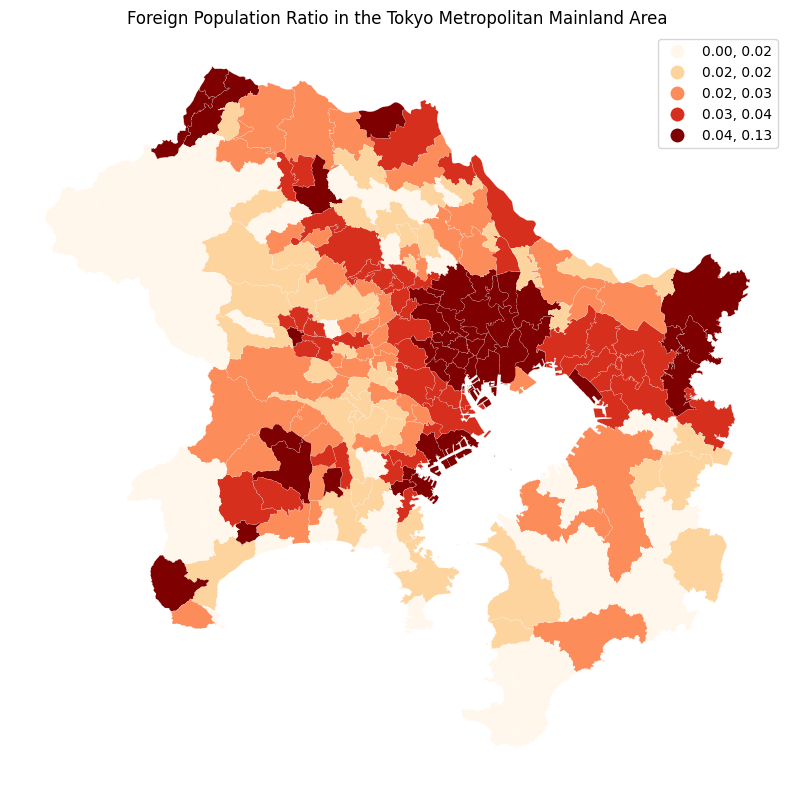

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_pop_dissolved.plot(
    column="foreign_ratio",
    cmap="OrRd",
    scheme="Quantiles",
    k=5,
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("Foreign Population Ratio in the Tokyo Metropolitan Mainland Area")
ax.set_axis_off()
plt.show()

In [31]:
tokyo_pop_dissolved_path = data_raw / "tokyo_pop_dissolved.geojson"
tokyo_pop_dissolved.to_file(tokyo_pop_dissolved_path, driver="GeoJSON")

print(tokyo_pop_dissolved_path)
print(tokyo_pop_dissolved_path.exists())

e:\rsch\laborJapan\data_raw\tokyo_pop_dissolved.geojson
True


In [32]:
tokyo_pop_dissolved.drop(columns="geometry").to_csv(
    data_raw / "tokyo_pop_dissolved.csv",
    index=False,
    encoding="utf-8-sig"
)